# This notebook is to outline the base steps I take to run an MLP model in Torch

In [5]:
# import packages

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler
import torch.optim as optim
import torch.nn.functional as F

from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

import pickle

import h5py
import numpy as np


import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap, TwoSlopeNorm, BoundaryNorm
import matplotlib.path as mpath
import matplotlib.patheffects as PathEffects


import xarray as xr
import pandas as pd

import glob
import os
import datetime

# define device to train the model on

# device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = 'cuda:1'
print(f"Using {device} device")

Using cuda:1 device


# Step 1: Reading in the data to be put into the ML model

In [3]:
# this block of code is mostly unchanged from how Chuck originally wrote it in scikit

def split_tvt(data_dict, fractions=[0.8,0.1,0.1]):
    keys = list(data_dict.keys())
    total_length = len(data_dict[keys[0]])
    train_start_ind, train_end_ind = 0, int(total_length*fractions[0])
    valid_start_ind, valid_end_ind = train_end_ind, int(total_length*(fractions[0]+fractions[1]))
    test_start_ind, test_end_ind = valid_end_ind, total_length
    
    train_dict = {k: data_dict[k][train_start_ind:train_end_ind] for k in keys}
    valid_dict = {k: data_dict[k][valid_start_ind:valid_end_ind] for k in keys}
    test_dict = {k: data_dict[k][test_start_ind:test_end_ind] for k in keys}
    
    return train_dict, valid_dict, test_dict


# Read in the training dataset
f = h5py.File('/mnt/mlnas01/cjohnson/caig/data/training_dataset_2.h5')
data = {}
for key in list(f.keys()):
    print('Reading...', key)
    data[key] = f[key][:]
f.close()

# print(data)

# Split our data into 3 dictionaries for training, validation, and testing
train_dict, valid_dict, test_dict = split_tvt(data, fractions=[0.8,0.1,0.1])

# Take our inputs/labels from the dictionary and create a 'design matrix' (rows=samples, columns=variables)
list_of_inputs = ['air_2m', 'air_700mb', 'air_800mb', 
                  'air_900mb', 'hgt_700mb', 'hgt_800mb', 'hgt_900mb', 
                  'pres_sfc', 'shum_2m', 'shum_700mb', 'shum_800mb', 'shum_900mb', 
                  'uwnd_10m', 'uwnd_700mb', 'uwnd_800mb', 'uwnd_900mb', 
                  'vwnd_10m', 'vwnd_700mb', 'vwnd_800mb', 'vwnd_900mb','lat_grid', 'lon_grid',
                  'omega_900mb','omega_700mb','omega_300mb', 'cape_sfc','cin_sfc',
                  'ulwrf_ntatFlx']

print(len(list_of_inputs))


labels = ['cloud_regime']
x_train = np.stack([train_dict[feature] for feature in list_of_inputs],axis=1)
x_valid = np.stack([valid_dict[feature] for feature in list_of_inputs],axis=1)
y_train = np.stack([train_dict[feature] for feature in labels],axis=1)
y_valid = np.stack([valid_dict[feature] for feature in labels],axis=1)

print(x_train.shape)

# Use the train mean and std dev to standardize our data
train_mean = np.nanmean(x_train,axis=0)
train_std = np.nanstd(x_train,axis=0)
x_train = (x_train-train_mean)/train_std
x_valid = (x_valid-train_mean)/train_std

# Flatten the labels to 1D arrays (sklearn expects 1D for classification)
y_train = y_train.ravel()
y_valid = y_valid.ravel()

# Convert & Re-index the labels (cloud regimes 1 to 12 --> 0 to 11)
y_train = y_train.astype(int) - 1
y_valid = y_valid.astype(int) - 1

print(x_train.shape, y_train.shape)

print(y_train.min(),y_train.max(), y_valid.min(), y_valid.max())

print(x_train.min(),x_train.max(), x_valid.min(), x_valid.max())


Reading... air_2m
Reading... air_700mb
Reading... air_800mb
Reading... air_900mb
Reading... aqua_cr_grid
Reading... cape_sfc
Reading... cin_sfc
Reading... cloud_regime
Reading... day
Reading... hgt_700mb
Reading... hgt_800mb
Reading... hgt_900mb
Reading... hour
Reading... lat_grid
Reading... lon_grid
Reading... month
Reading... omega_300mb
Reading... omega_700mb
Reading... omega_900mb
Reading... pres_sfc
Reading... shum_2m
Reading... shum_700mb
Reading... shum_800mb
Reading... shum_900mb
Reading... terra_cr_grid
Reading... ulwrf_ntatFlx
Reading... uwnd_10m
Reading... uwnd_700mb
Reading... uwnd_800mb
Reading... uwnd_900mb
Reading... vwnd_10m
Reading... vwnd_700mb
Reading... vwnd_800mb
Reading... vwnd_900mb
Reading... year
28
(3610400, 28)
(3610400, 28) (3610400,)
0 11 0 11
-51.034653 23.893013 -41.216682 23.095528


# Step 2: Take a look at how the labels are distributed, and create weights

In [4]:
# seeing how the data is distributed
counts = Counter(y_train)
sorted_counts = sorted(counts.items(), key=lambda k: k[0])
sorted_counts

[(np.int64(0), 33592),
 (np.int64(1), 43764),
 (np.int64(2), 84032),
 (np.int64(3), 139372),
 (np.int64(4), 206157),
 (np.int64(5), 329948),
 (np.int64(6), 237635),
 (np.int64(7), 197876),
 (np.int64(8), 203853),
 (np.int64(9), 381856),
 (np.int64(10), 1386255),
 (np.int64(11), 366060)]

In [7]:
# creating weights for the labels

class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() # normalized
print(class_weights)
class_weights = torch.tensor(class_weights, dtype = torch.float32).to(device)

[0.29824228 0.22892228 0.11922309 0.07188355 0.04859672 0.03036404
 0.04215942 0.05063047 0.04914598 0.02623647 0.00722706 0.02736861]


# Step 3: Set up the MLP model. Most of this code is a direct copy/paste from Imme's tutorial ( https://colab.research.google.com/drive/10VQ0oBMSoe61i5OleNisA5bidAVHdqqS?usp=drive_link )

In [8]:
# Define class to create data set in pytorch format
class CustomDataset(Dataset):
  # Constructor
  def __init__(self, data, labels):
        self.data   = torch.tensor(data, dtype=torch.float32).to(device=device)  # input portion of sample
        self.labels = torch.tensor(labels, dtype=torch.long).to(device=device)  # correct output portion of sample

  def __len__(self):
        return len(self.labels)  # of samples = # of labels

  def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]   # return a single sample

# create the training dataset

y_valid_np = np.array(y_valid)
y_train_np = np.array(y_train)

my_training_dataset = CustomDataset( x_train, y_train_np )

my_validation_dataset = CustomDataset( x_valid, y_valid_np )

# create a data loader to handle this dataset
batch_size = 1024   # data will be loaded in "chunks" for model training.  Chunk size: batch_size.
my_training_loader = DataLoader( my_training_dataset, 
                                 batch_size = batch_size, 
                                 shuffle = True)#,
                               #sampler=sampler)

my_validation_loader = DataLoader( my_validation_dataset, 
                                   batch_size = batch_size, 
                                   shuffle = False)

# Training data is now ready to be used.
# Note that the dataloader return data in batches of the size set above, rather than individual samples



In [9]:
# Define simple neural network architecture as a class

# Example: build a simple, fully-connected network
# (aka multi-layer perceptron).
# Nodes of each layer are connected to all nodes of the next layer.

# Simple NN models are build in layers,
# i.e., one layer after the other with
# connections only between neighboring layers.
# That's called a "Sequential" model.

n_units = 64

class NeuralNetwork(nn.Module):
    def __init__(self,input_dim=28, hidden_dim=32, output_dim=12):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            # First hidden layer: fully-connected layer with n_units units and activation function 'relu'.
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            # Second hidden layer: fully-connected layer with n_units units and activation function 'relu'.
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            # Output layer:  just 1 node and no activation function
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        NN_estimate = self.linear_relu_stack(x)
        return NN_estimate


# Create a NN using the class definition above and move it to the device (GPU).
# Model weights are initialized as random values.
my_simple_NN = NeuralNetwork().to(device)

# Model is now ready to be trained.

In [10]:
# Train the model

# train_loop: loops over our optimization code to train NN.

def train_loop(dataloader, NN_model, loss_fn, optimizer):
    n_samples = len(dataloader.dataset)  # number of samples in dataset
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    NN_model.train()
    loss_sum = 0  # initialize loss sum to 0

    # retrieve one batch of data, while also getting the index of the batch (starting at 0)
    for batch_counter, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = NN_model(X)    # compute NN prediction
        loss = loss_fn(pred, y)  # calculate loss by comparing NN prediction t correct label for training data

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loss = loss.item()  # this is the average loss across current batch

        if batch_counter % 50 == 0:  # for every 100th batch, print intermediate results
          samples_done = batch_counter * batch_size + len(X)
          print(f"Training loss: {loss:>7f}  [{samples_done:>5d}/{n_samples:>5d}]")

        loss_sum += loss  # add up all losses up to here

    # At end of epoch, print loss obtained in last epoch:
    # average loss of last batch (note: last batch might not be representative or full batch size)
    print(f"Training loss: {loss:>8f}  [last batch in epoch]\n")

    num_batches = len(dataloader)  # number of batches
    average_loss = loss_sum/num_batches  # Divide sum of average batch losses by number of batches to get overall average
    print(f"Avg Training loss: {average_loss:>8f}\n")

    return average_loss


# val_test_loop: evaluates the model’s performance against validation or test data.

def val_test_loop(dataloader, NN_model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    NN_model.eval()
    loss_sum = 0  # set error variable to 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        # Retrieve one batch of data
        for X, y in dataloader:
            pred = NN_model(X)
            loss_sum += loss_fn(pred, y).item()  # add average loss from single batch to sum

    num_batches = len(dataloader)  # number of batches
    average_loss = loss_sum/num_batches  # Divide sum of all errors by number of batches to get overall average
    print(f"Avg Validation loss: {average_loss:>8f}\n")

    return average_loss

# Step 4: Run the model! And time it.
## This setup takes 6 mins, 13 sec to run

In [11]:
%%time

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

my_simple_NN.apply(init_weights)

# Choose a loss function, i.e., the function to be minimized by NN
loss_fn = nn.CrossEntropyLoss(weight=class_weights)   # mean square error ... use crossentropy for classification


# Gradient descent training method:
#   NNs use gradient descent methods to determine the parameters.
#   There are different strategies to adaptively choose the learning rate (step size).
#   Gradient descent methods use adaptive learning rates (step size).
#   Common choice: Adam
#   See http://ruder.io/optimizing-gradient-descent/index.html#adam

# choose a standard optimizer and standard learning rate
learning_rate = 0.0001
optimizer = optim.Adam(my_simple_NN.parameters(), lr=learning_rate, weight_decay=1e-5)
# scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.96)

# Define how many rounds of training to do.  Each epoch runs through the training data once.
n_epochs = 10

# initialize empty arrays to keep track of model convergence
train_loss = []
validation_loss = []

# TRAIN THE NN

# sometimes i get an error when trying to run the MLP, and uncommenting the next line fixes the error
# !export CUDA_LAUNCH_BLOCKING=1

for epoch in range(n_epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    
    t_loss = train_loop(my_training_loader, my_simple_NN, loss_fn, optimizer)
    v_loss = val_test_loop(my_validation_loader, my_simple_NN, loss_fn)
    train_loss.append(t_loss)  # track training loss across epochs
    validation_loss.append(v_loss)  # track validation loss across epochs
    # scheduler.step()
print("Done!")

# Note:  you can run this cell multiple times to CONTINUE training the already trained NN.


Epoch 1
-------------------------------
Training loss: 2.556276  [ 1024/3610400]
Training loss: 2.489611  [52224/3610400]
Training loss: 2.419981  [103424/3610400]
Training loss: 2.386987  [154624/3610400]
Training loss: 2.339019  [205824/3610400]
Training loss: 2.336091  [257024/3610400]
Training loss: 2.288038  [308224/3610400]
Training loss: 2.240645  [359424/3610400]
Training loss: 2.254457  [410624/3610400]
Training loss: 2.199183  [461824/3610400]
Training loss: 2.169968  [513024/3610400]
Training loss: 2.090832  [564224/3610400]
Training loss: 2.102084  [615424/3610400]
Training loss: 2.095629  [666624/3610400]
Training loss: 2.033054  [717824/3610400]
Training loss: 2.087749  [769024/3610400]
Training loss: 2.017706  [820224/3610400]
Training loss: 2.049787  [871424/3610400]
Training loss: 2.037982  [922624/3610400]
Training loss: 2.015138  [973824/3610400]
Training loss: 1.957690  [1025024/3610400]
Training loss: 1.927797  [1076224/3610400]
Training loss: 1.937901  [1127424/36

# Step 5: Take a look at a confusion matrix to see how the model is doing

In [12]:
# Make sure your model is in eval mode
my_simple_NN.eval()

# Disable gradient tracking for speed and memory
with torch.no_grad():
    # Move validation data to the same device as the model
    X_valid_torch = torch.tensor(x_valid, dtype=torch.float32).to(device)
    
    # Get raw outputs (logits)
    logits = my_simple_NN(X_valid_torch)
    
    # Convert logits to probabilities (like sklearn’s predict_proba)
    y_valid_pred_prob = torch.softmax(logits, dim=1).cpu().numpy()

    print(y_valid_pred_prob.shape)
    
    # Take argmax for predicted class indices
    y_valid_pred = torch.argmax(logits, dim=1).cpu().numpy()

    #print(y_valid_pred)

# labels
y_valid_true = np.array(y_valid_np)

print(y_valid_pred_prob.shape)
print(y_valid_pred.shape)

(451300, 12)
(451300, 12)
(451300,)


In [13]:
print("\nClassification Report:")
print(classification_report(
    y_valid_true,
    y_valid_pred,
    digits=4
))


Classification Report:
              precision    recall  f1-score   support

           0     0.1006    0.5455    0.1699      3463
           1     0.0990    0.5091    0.1658      4632
           2     0.2537    0.5029    0.3373     10332
           3     0.1686    0.2754    0.2092     16416
           4     0.2505    0.3297    0.2847     25390
           5     0.3017    0.3150    0.3082     38250
           6     0.2553    0.3310    0.2883     24957
           7     0.3079    0.6080    0.4087     37884
           8     0.2015    0.3151    0.2458     34440
           9     0.3170    0.3707    0.3417     46178
          10     0.6559    0.0850    0.1505    173339
          11     0.3695    0.5188    0.4316     36019

    accuracy                         0.2815    451300
   macro avg     0.2734    0.3922    0.2785    451300
weighted avg     0.4226    0.2815    0.2567    451300



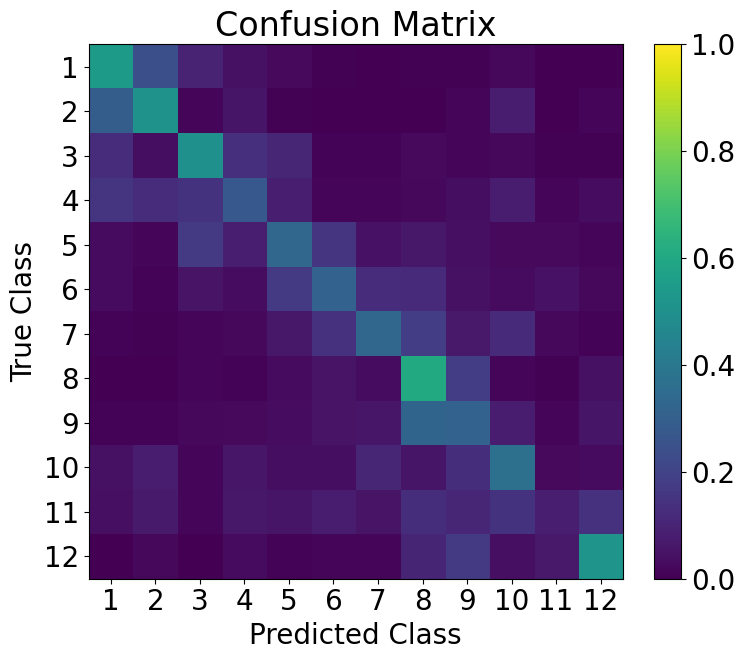

In [16]:
cm = confusion_matrix(y_valid_true, y_valid_pred)

# Normalize rows
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm_norm, cmap='viridis', vmin=0, vmax=1)

plt.rcParams.update({'font.size': 20})

plt.colorbar(im, fraction=0.046)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title(f"Confusion Matrix")#\nInput: All data")

ticks = np.arange(1,13,1)

plt.xticks(range(12), ticks)
plt.yticks(range(12), ticks)

plt.tight_layout()
plt.show()